# AST V1 Classification: 3s / 25 Segments

This notebook trains and evaluates the first Audio Spectrogram Transformer variant using 25 random 3-second segments per track.

The model is trained on segment-level inputs. For final evaluation, segment-level predictions are aggregated to track-level predictions.

In [1]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: j:\Documents\FH\Git Repo Processing\MA-music-genre-classification-mfcc


In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import pandas as pd
from transformers import AutoProcessor, ASTModel, ASTPreTrainedModel, ASTConfig
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torch.nn as nn
import torch.nn.functional as F
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score
from src.config import (
    AST_AUDIO_DIR,
    AST_METADATA_CSV,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)

In [ ]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

# --- General ---
VERBOSE = 1
MODEL_NAME = "AST_V1_3s_25"
DATA_DIR = str(AST_AUDIO_DIR)
CSV_FILE = str(AST_METADATA_CSV)

# --- Segment sampling ---
SEGMENT_LENGTH_SECONDS = 3       # Each model input is a random 3-second segment
N_RANDOM_SEGMENTS = 25           # Number of random segments per track
SAMPLE_RATE = 16000              # AST expects 16 kHz audio

# --- Dataset ---
REDUCTION_FACTOR = 1   # Percentage of data to keep

# --- Training ---
BATCH_SIZE = 32
MIN_LEARNING_RATE = 1e-6
LEARNING_RATE = 3e-4
EPOCHS = 30
UNFREEZE_EPOCH = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL = "MIT/ast-finetuned-audioset-16-16-0.442"
ACCUMULATION_STEPS = 4  # Effective batch size = BATCH_SIZE * ACCUMULATION_STEPS if used

# ----------------- FILTER SETTINGS ------------------------
TOP_K_GENRES = 8  # Only keep top K frequent genres (None = all)
EXCLUDE_GENRES = ['International', 'Instrumental', 'Experimental']  # List of genres to exclude
SAMPLES_PER_GENRE = 533 # Max number of original tracks per genre before segment extraction (None = all)

VAL_SPLIT_RATIO = 0.1 # Validation set ratio on track level
TEST_SPLIT_RATIO = 0.1 # Test set ratio on track level

In [ ]:
# ============================================================
# DATA REDUCTION FUNCTION
# Keeps only a specified percentage of the dataset
# ============================================================

def reduce_dataset(df, reduction_factor, seed=42):
    """
    Reduce dataset size by randomly sampling a percentage of rows.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
    reduction_factor : float
        Fraction of data to keep (0.0 - 1.0).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pandas.DataFrame
        Reduced dataset.
    """

    if reduction_factor >= 1.0:
        return df

    df_reduced = df.sample(frac=reduction_factor, random_state=seed)

    if VERBOSE:
        print(f"\nDataset reduced:")
        print(f"Original size: {len(df)}")
        print(f"New size: {len(df_reduced)} ({reduction_factor*100:.1f}%)")

    return df_reduced

In [ ]:
# Create SpecAugment transforms
# These randomly mask parts of the spectrogram during training
freq_masking = T.FrequencyMasking(freq_mask_param=30)  # Masks random frequency bands
time_masking = T.TimeMasking(time_mask_param=100)      # Masks random time segments

def apply_spec_augment(spec):
    """
    Apply SpecAugment to a spectrogram.

    Parameters
    ----------
    spec : torch.Tensor
        Input spectrogram with shape [Batch, Frequency, Time].

    Returns
    -------
    torch.Tensor
        Augmented spectrogram with randomly masked frequency
        and time regions.
    """

    # Apply random frequency masking
    spec = freq_masking(spec)

    # Apply random time masking
    spec = time_masking(spec)

    return spec

In [ ]:
# ----------- LOAD CSV AND FILTER EXISTING FILES ----------- #
df = pd.read_csv(CSV_FILE, dtype={'track_id': str, 'track_genre_top': str})

# Ensure track_id always has 6 digits
df['filename'] = df['track_id'].str.zfill(6) + ".wav"

# Keep only files that exist on disk
existing_files = set(os.listdir(DATA_DIR))
df_filtered = df[df['filename'].isin(existing_files)].reset_index(drop=True)

print(f"Files in CSV: {len(df)}")
print(f"Files found on disk: {len(df_filtered)}")


# ----------- EXCLUDE GENRES AND SELECT TOP K ----------- #

# Remove unwanted genres
if EXCLUDE_GENRES:
    df_filtered = df_filtered[~df_filtered['track_genre_top'].isin(EXCLUDE_GENRES)]
    print(f"Excluded genres: {EXCLUDE_GENRES}")
    print(f"Remaining files: {len(df_filtered)}")

# Select top K most frequent genres
if TOP_K_GENRES is not None:

    genre_counts = df_filtered['track_genre_top'].value_counts()

    top_genres = genre_counts.head(TOP_K_GENRES).index.tolist()

    df_filtered = df_filtered[df_filtered['track_genre_top'].isin(top_genres)]

    print(f"\n--- Filtering Top {TOP_K_GENRES} Genres ---")
    print(f"Remaining genres: {top_genres}")
    print(f"Files after filter: {len(df_filtered)}")


# ----------- OPTIONAL: REDUCE DATASET SIZE ----------- #
df_filtered = reduce_dataset(df_filtered, REDUCTION_FACTOR)


# ----------- BALANCING AND DATA SPLIT ----------- #

train_val_rows, test_rows = [], []
train_rows, val_rows = [], []

grouped = df_filtered.groupby("track_genre_top")

print("\n--- Balancing & Splitting ---")

for genre, group in grouped:

    n_available = len(group)

    # Limit samples per genre if configured
    if SAMPLES_PER_GENRE is not None and n_available > SAMPLES_PER_GENRE:
        group_subset = group.sample(n=SAMPLES_PER_GENRE, random_state=RANDOM_STATE)
        print(f"Genre '{genre}': reduced to {SAMPLES_PER_GENRE}")
    else:
        group_subset = group
        print(f"Genre '{genre}': using {n_available} samples")

    # Split test set
    test_size_n = max(1, int(len(group_subset) * TEST_SPLIT_RATIO))

    train_val_group, test_group = train_test_split(
        group_subset,
        test_size=test_size_n,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    test_rows.append(test_group)

    # Split validation set
    val_size_n = max(1, int(len(group_subset) * VAL_SPLIT_RATIO))

    train_group, val_group = train_test_split(
        train_val_group,
        test_size=val_size_n,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    train_rows.append(train_group)
    val_rows.append(val_group)


# Combine final dataframes
train_df = pd.concat(train_rows).reset_index(drop=True)
val_df = pd.concat(val_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)


# ----------- LABEL ENCODER ----------- #
le = LabelEncoder()
le.fit(train_df['track_genre_top'])

print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Files in CSV: 106574
Files found on disk: 103871
Excluded genres: ['International', 'Instrumental', 'Experimental']
Remaining files: 90240

--- Filtering Top 8 Genres ---
Remaining genres: ['Rock', 'Electronic', 'Hip-Hop', 'Folk', 'Pop', 'Classical', 'Jazz', 'Old-Time / Historic']
Files after filter: 33606

--- Balancing & Splitting ---
Genre 'Classical': reduced to 533
Genre 'Electronic': reduced to 533
Genre 'Folk': reduced to 533
Genre 'Hip-Hop': reduced to 533
Genre 'Jazz': reduced to 533
Genre 'Old-Time / Historic': reduced to 533
Genre 'Pop': reduced to 533
Genre 'Rock': reduced to 533
Class mapping: {'Classical': np.int64(0), 'Electronic': np.int64(1), 'Folk': np.int64(2), 'Hip-Hop': np.int64(3), 'Jazz': np.int64(4), 'Old-Time / Historic': np.int64(5), 'Pop': np.int64(6), 'Rock': np.int64(7)}


In [ ]:
# -------------------------------
# CUSTOM DATASET
# -------------------------------
class CSVDataset(Dataset):
    """
    PyTorch dataset for AST using segment-level samples.

    Each original track produces n_segments random 3-second samples.
    The track split is created before this Dataset is instantiated, so all
    segments from the same track remain in the same train/val/test split.
    """
    def __init__(
        self,
        df,
        root_dir,
        processor,
        segment_length_seconds=3,
        n_segments=25,
        sample_rate=16000,
        le=None,
        random_state=RANDOM_STATE
    ):
        self.processor = processor
        self.segment_length_seconds = segment_length_seconds
        self.n_segments = n_segments
        self.sample_rate = sample_rate
        self.root_dir = root_dir
        self.df = df.copy().reset_index(drop=True)
        self.le = le
        self.random_state = random_state

        # Store labels as integers
        self.df['label'] = self.le.transform(self.df['track_genre_top'])

        # Precompute a deterministic segment index per dataset item.
        # Actual start positions are sampled after loading, because audio lengths can differ.
        self.index_map = [
            (row_idx, segment_idx)
            for row_idx in range(len(self.df))
            for segment_idx in range(self.n_segments)
        ]

    def __len__(self):
        return len(self.index_map)

    def _load_audio(self, file_path):
        try:
            waveform_np, sr = sf.read(file_path, dtype="float32")

            # Ensure shape: (channels, samples)
            if waveform_np.ndim == 1:
                waveform_np = np.expand_dims(waveform_np, axis=0)
            elif waveform_np.ndim == 2 and waveform_np.shape[0] > waveform_np.shape[1]:
                waveform_np = waveform_np.T

        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            waveform_np = np.zeros((1, self.sample_rate * self.segment_length_seconds), dtype="float32")
            sr = self.sample_rate

        waveform = torch.tensor(waveform_np, dtype=torch.float32)

        # Resample to target sample rate if needed
        if sr != self.sample_rate:
            waveform = torch.nn.functional.interpolate(
                waveform.unsqueeze(0),
                size=int(self.sample_rate * waveform.shape[1] / sr),
                mode="linear",
                align_corners=False
            ).squeeze(0)

        # Convert stereo/multi-channel to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        return waveform

    def _random_crop_or_pad(self, waveform, row_idx, segment_idx):
        target_len = self.sample_rate * self.segment_length_seconds
        current_len = waveform.shape[1]

        # Pad short files to at least 3 seconds
        if current_len < target_len:
            waveform = torch.nn.functional.pad(waveform, (0, target_len - current_len))
            current_len = waveform.shape[1]

        max_start = current_len - target_len

        # Deterministic random start for reproducibility
        rng = np.random.default_rng(self.random_state + row_idx * self.n_segments + segment_idx)
        start = int(rng.integers(0, max_start + 1)) if max_start > 0 else 0

        return waveform[:, start:start + target_len]

    def __getitem__(self, idx):
        row_idx, segment_idx = self.index_map[idx]
        row = self.df.iloc[row_idx]

        file_path = os.path.join(self.root_dir, str(row['filename']))
        label = int(row['label'])

        waveform = self._load_audio(file_path)
        waveform = self._random_crop_or_pad(waveform, row_idx, segment_idx)

        # Convert to NumPy for Hugging Face AST processor
        waveform_final_np = waveform.squeeze().numpy()

        inputs = self.processor(
            waveform_final_np,
            sampling_rate=self.sample_rate,
            return_tensors="pt"
        )
        input_values = inputs["input_values"].squeeze(0)

        return input_values, torch.tensor(label, dtype=torch.long), row["track_id"]

In [ ]:
class CustomASTClassifier(ASTPreTrainedModel):
    """
    Custom Audio Spectrogram Transformer (AST) classifier with an additional
    trainable head on top. Supports optional freezing of the AST backbone.
    """
    def __init__(self, config, freeze_backbone=False):
        super().__init__(config)
        self.num_labels = config.num_labels

        # -------------------------------
        # AST backbone
        # -------------------------------
        self.audio_spectrogram_transformer = ASTModel(config)
        if freeze_backbone:
            for param in self.audio_spectrogram_transformer.parameters():
                param.requires_grad = False  # Freeze backbone if needed

        # -------------------------------
        # Classifier head with residual connection
        # -------------------------------
        self.head_linear1 = nn.Linear(config.hidden_size, 512)  # First linear layer
        self.head_ln1 = nn.LayerNorm(512)                        # LayerNorm
        self.dropout1 = nn.Dropout(0.4)                         # Dropout for regularization

        self.head_linear2 = nn.Linear(512, 512)                 # Second linear layer (same dimension for residual)
        self.head_ln2 = nn.LayerNorm(512)
        self.dropout2 = nn.Dropout(0.3)

        self.classifier_out = nn.Linear(512, config.num_labels) # Final classification layer

        self.init_weights()  # Initialize weights

    def forward(self, input_values, labels=None, **kwargs):
        """
        Forward pass.

        Args:
            input_values (Tensor): input audio features (e.g., spectrograms)
            labels (Tensor, optional): ground truth labels for computing loss

        Returns:
            dict with 'loss' and 'logits' if labels provided, else logits
        """
        # -------------------------------
        # AST backbone forward
        # -------------------------------
        outputs = self.audio_spectrogram_transformer(input_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token representation

        # -------------------------------
        # Head forward with residual
        # -------------------------------
        x = self.head_linear1(cls_output)
        x = self.head_ln1(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        res = x  # Save for residual connection
        x = self.head_linear2(x)
        x = self.head_ln2(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = x + res  # Add residual

        logits = self.classifier_out(x)  # Final logits

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return {"loss": loss, "logits": logits} if loss is not None else logits


# -------------------------------
# Initialization
# -------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load AST configuration with number of output labels
config = ASTConfig.from_pretrained(
    MODEL,
    num_labels=8
)

# Load model with optional backbone freezing
model = CustomASTClassifier.from_pretrained(
    MODEL,
    config=config,
    freeze_backbone=False  # True if you want to train only the head initially
)

model.to(DEVICE)
print("Model loaded and ready on device:", DEVICE)

Some weights of CustomASTClassifier were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-16-16-0.442 and are newly initialized: ['classifier_out.bias', 'classifier_out.weight', 'head_linear1.bias', 'head_linear1.weight', 'head_linear2.bias', 'head_linear2.weight', 'head_ln1.bias', 'head_ln1.weight', 'head_ln2.bias', 'head_ln2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and ready on device: cuda


In [ ]:
class CustomASTClassifier(ASTPreTrainedModel):
    """
    Custom Audio Spectrogram Transformer (AST) classifier with an additional
    trainable head on top. Supports optional freezing of the AST backbone.
    """
    def __init__(self, config, freeze_backbone=False):
        super().__init__(config)
        self.num_labels = config.num_labels

        # -------------------------------
        # AST backbone
        # -------------------------------
        self.audio_spectrogram_transformer = ASTModel(config)
        if freeze_backbone:
            for param in self.audio_spectrogram_transformer.parameters():
                param.requires_grad = False  # Freeze backbone if needed

        # -------------------------------
        # Classifier head with residual connection
        # -------------------------------
        self.head_linear1 = nn.Linear(config.hidden_size, 512)  # First linear layer
        self.head_ln1 = nn.LayerNorm(512)                        # LayerNorm
        self.dropout1 = nn.Dropout(0.4)                         # Dropout for regularization

        self.head_linear2 = nn.Linear(512, 512)                 # Second linear layer (same dimension for residual)
        self.head_ln2 = nn.LayerNorm(512)
        self.dropout2 = nn.Dropout(0.3)

        self.classifier_out = nn.Linear(512, config.num_labels) # Final classification layer

        self.init_weights()  # Initialize weights

    def forward(self, input_values, labels=None, **kwargs):
        """
        Forward pass.

        Args:
            input_values (Tensor): input audio features (e.g., spectrograms)
            labels (Tensor, optional): ground truth labels for computing loss

        Returns:
            dict with 'loss' and 'logits' if labels provided, else logits
        """
        # -------------------------------
        # AST backbone forward
        # -------------------------------
        outputs = self.audio_spectrogram_transformer(input_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # Use [CLS] token representation

        # -------------------------------
        # Head forward with residual
        # -------------------------------
        x = self.head_linear1(cls_output)
        x = self.head_ln1(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        res = x  # Save for residual connection
        x = self.head_linear2(x)
        x = self.head_ln2(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = x + res  # Add residual

        logits = self.classifier_out(x)  # Final logits

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return {"loss": loss, "logits": logits} if loss is not None else logits


# -------------------------------
# Initialization
# -------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load AST configuration with number of output labels
config = ASTConfig.from_pretrained(
    MODEL,
    num_labels=8
)

# Load model with optional backbone freezing
model = CustomASTClassifier.from_pretrained(
    MODEL,
    config=config,
    freeze_backbone=False  # True if you want to train only the head initially
)

model.to(DEVICE)
print("Model loaded and ready on device:", DEVICE)

Some weights of CustomASTClassifier were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-16-16-0.442 and are newly initialized: ['classifier_out.bias', 'classifier_out.weight', 'head_linear1.bias', 'head_linear1.weight', 'head_linear2.bias', 'head_linear2.weight', 'head_ln1.bias', 'head_ln1.weight', 'head_ln2.bias', 'head_ln2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and ready on device: cuda


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Segment samples -> Train: 85400, Val: 10600, Test: 10600
Each track contributes 25 random segments of 3 seconds.
Epoch 1/30 | Train Loss: 1.6043 | Val Loss: 1.1319 | Val Acc: 0.6979
Epoch 2/30 | Train Loss: 1.0745 | Val Loss: 1.0909 | Val Acc: 0.7207
Epoch 3/30 | Train Loss: 0.9892 | Val Loss: 1.0746 | Val Acc: 0.7267
Epoch 4/30 | Train Loss: 0.9279 | Val Loss: 1.0891 | Val Acc: 0.7239
Epoch 5/30 | Train Loss: 0.8787 | Val Loss: 1.0902 | Val Acc: 0.7314
Epoch 5: Unfreezing last 2 transformer layers
Epoch 6/30 | Train Loss: 0.8485 | Val Loss: 1.1008 | Val Acc: 0.7271
Epoch 7/30 | Train Loss: 0.8228 | Val Loss: 1.0979 | Val Acc: 0.7324
Early stopping triggered

Training finished. Creating plots...


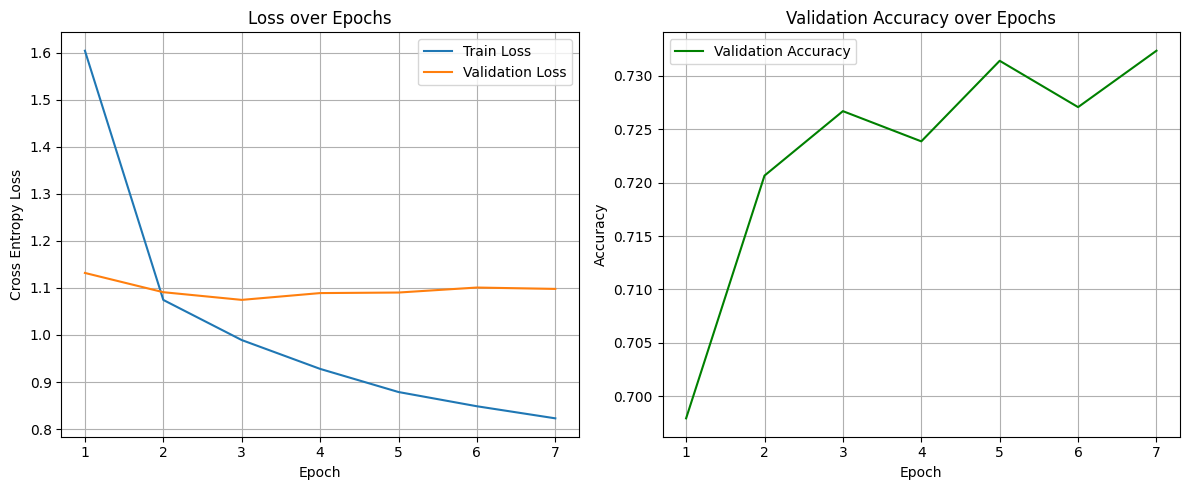

In [ ]:
# ------------------------------------------------------------
# PROCESSOR & MODEL
# ------------------------------------------------------------

# Load the AST processor (handles feature extraction)
processor = AutoProcessor.from_pretrained(MODEL)

# ------------------------------------------------------------
# FREEZE BACKBONE
# ------------------------------------------------------------

# Freeze the full AST backbone to train only the classifier head
for param in model.audio_spectrogram_transformer.parameters():
    param.requires_grad = False

# Layers of the classification head that remain trainable
head_layers = [
    model.head_linear1,
    model.head_ln1,
    model.head_linear2,
    model.head_ln2,
    model.classifier_out
]

# Enable training for classifier head
for layer in head_layers:
    for param in layer.parameters():
        param.requires_grad = True


# ------------------------------------------------------------
# DATASET & DATALOADER
# ------------------------------------------------------------

# Create dataset objects
train_dataset = CSVDataset(
    train_df,
    DATA_DIR,
    processor,
    segment_length_seconds=SEGMENT_LENGTH_SECONDS,
    n_segments=N_RANDOM_SEGMENTS,
    sample_rate=SAMPLE_RATE,
    le=le,
    random_state=RANDOM_STATE
)
val_dataset = CSVDataset(
    val_df,
    DATA_DIR,
    processor,
    segment_length_seconds=SEGMENT_LENGTH_SECONDS,
    n_segments=N_RANDOM_SEGMENTS,
    sample_rate=SAMPLE_RATE,
    le=le,
    random_state=RANDOM_STATE + 10_000
)
test_dataset = CSVDataset(
    test_df,
    DATA_DIR,
    processor,
    segment_length_seconds=SEGMENT_LENGTH_SECONDS,
    n_segments=N_RANDOM_SEGMENTS,
    sample_rate=SAMPLE_RATE,
    le=le,
    random_state=RANDOM_STATE + 20_000
)

# Create dataloaders
print(f"Segment samples -> Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Each track contributes {N_RANDOM_SEGMENTS} random segments of {SEGMENT_LENGTH_SECONDS} seconds.")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# ------------------------------------------------------------
# STORAGE FOR TRAINING METRICS
# ------------------------------------------------------------

train_losses = []
val_losses = []
val_accuracies = []


# ------------------------------------------------------------
# TRAINING SETUP
# ------------------------------------------------------------

num_epochs = 30
learning_rate = 2e-5

# Warmup steps (10% of total training steps)
warmup_steps = int(0.1 * len(train_loader) * num_epochs)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=0.01
)

# Learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=len(train_loader) * num_epochs
)

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# TRAINING PARAMETERS
# ------------------------------------------------------------
best_val_loss = float("inf")
patience = 4
patience_counter = 0


# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # UNFREEZE LAST TRANSFORMER LAYERS AFTER SOME EPOCHS
    # --------------------------------------------------------
    if epoch == UNFREEZE_EPOCH:

        print(f"Epoch {epoch}: Unfreezing last 2 transformer layers")

        for layer in model.audio_spectrogram_transformer.encoder.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Reinitialize optimizer to include newly trainable parameters
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-5,
            weight_decay=1e-4
        )

        remaining_steps = len(train_loader) * (EPOCHS - epoch)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * remaining_steps),
            num_training_steps=remaining_steps
        )

    # --------------------------------------------------------
    # TRAINING PHASE
    # --------------------------------------------------------

    model.train()
    total_train_loss = 0

    for batch in train_loader:

        inputs = batch[0].to(DEVICE)
        labels = batch[1].to(DEVICE)

        # AST expects input shape [batch, time, frequency]
        # Remove channel dimension if necessary
        if inputs.dim() == 4:
            inputs = inputs.squeeze(1)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs, labels=labels)
        loss = outputs["loss"]

        # Backpropagation
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)


    # --------------------------------------------------------
    # VALIDATION PHASE
    # --------------------------------------------------------

    model.eval()

    total_val_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():

        for batch in val_loader:

            inputs = batch[0].to(DEVICE)
            labels = batch[1].to(DEVICE)

            if inputs.dim() == 4:
                inputs = inputs.squeeze(1)

            outputs = model(inputs, labels=labels)

            val_loss = outputs["loss"]
            logits = outputs["logits"]

            total_val_loss += val_loss.item()

            preds = torch.argmax(logits, dim=1)

            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct_predictions / total_samples

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0

        # Optional: save best model
        # torch.save(model.state_dict(), "best_model.pt")

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break


print("\nTraining finished. Creating plots...")


# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

epochs_range = np.arange(1, epoch + 2)

# Plot loss curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy", color="green")
plt.title("Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------------------
# SEGMENT-LEVEL AND TRACK-LEVEL EVALUATION
# --------------------------------------------------------------

def _get_logits(outputs):
    """
    Return logits for both possible model outputs:
    - plain tensor logits
    - dictionary with key 'logits'
    """
    if isinstance(outputs, dict):
        return outputs["logits"]
    return outputs


def collect_segment_predictions(model, loader):
    """
    Run inference once and collect one row per 3-second segment.

    Returns
    -------
    pandas.DataFrame
        Segment-level predictions with track_id, true label, predicted label
        and class probabilities.
    """
    model.eval()

    rows = []

    with torch.no_grad():
        for inputs, labels, track_ids in loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            # AST expects input shape [batch, time, frequency]
            if inputs.dim() == 4:
                inputs = inputs.squeeze(1)

            outputs = model(inputs)
            logits = _get_logits(outputs)
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            for track_id, true_label, pred_label, proba in zip(
                track_ids,
                labels.cpu().numpy(),
                predictions.cpu().numpy(),
                probabilities.cpu().numpy()
            ):
                rows.append({
                    "track_id": str(track_id),
                    "true_label": int(true_label),
                    "pred_label": int(pred_label),
                    "true_genre": le.inverse_transform([int(true_label)])[0],
                    "predicted_genre": le.inverse_transform([int(pred_label)])[0],
                    "probabilities": proba
                })

    return pd.DataFrame(rows)


def plot_confusion_matrix_from_labels(y_true, y_pred, title):
    """Plot a confusion matrix for the given labels."""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def evaluate_segment_predictions(segment_df, set_name):
    """
    Evaluate predictions on segment level.
    Each 3-second segment counts as one sample.
    """
    print(f"\n--- {set_name} Segment-Level Evaluation ---")

    y_true = segment_df["true_label"].to_numpy()
    y_pred = segment_df["pred_label"].to_numpy()

    print(f"Segments evaluated: {len(segment_df)}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro-F1: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    plot_confusion_matrix_from_labels(
        y_true,
        y_pred,
        title=f"Confusion Matrix ({set_name}, Segment-Level)"
    )


def aggregate_predictions_to_track(segment_df, method="mean_probability"):
    """
    Aggregate 25 segment predictions to one final prediction per track.

    Parameters
    ----------
    segment_df : pandas.DataFrame
        Output of collect_segment_predictions().
    method : str
        'mean_probability' averages the softmax probabilities of all segments.
        'majority_vote' uses the most frequent segment prediction.

    Returns
    -------
    pandas.DataFrame
        One row per track with the aggregated prediction.
    """
    if method not in {"mean_probability", "majority_vote"}:
        raise ValueError("method must be 'mean_probability' or 'majority_vote'")

    track_rows = []

    for track_id, group in segment_df.groupby("track_id"):
        true_label = int(group["true_label"].iloc[0])

        if method == "mean_probability":
            mean_proba = np.vstack(group["probabilities"].to_numpy()).mean(axis=0)
            pred_label = int(np.argmax(mean_proba))

        else:  # majority_vote
            vote_counts = np.bincount(
                group["pred_label"].to_numpy(),
                minlength=len(le.classes_)
            )
            pred_label = int(np.argmax(vote_counts))

        track_rows.append({
            "track_id": track_id,
            "true_label": true_label,
            "pred_label": pred_label,
            "true_genre": le.inverse_transform([true_label])[0],
            "predicted_genre": le.inverse_transform([pred_label])[0],
            "n_segments": len(group),
            "aggregation_method": method
        })

    return pd.DataFrame(track_rows)


def evaluate_track_predictions(track_df, set_name, method):
    """
    Evaluate predictions on track level.
    The 25 segment predictions of one track count as one final prediction.
    """
    print(f"\n--- {set_name} Track-Level Evaluation ({method}) ---")

    y_true = track_df["true_label"].to_numpy()
    y_pred = track_df["pred_label"].to_numpy()

    print(f"Tracks evaluated: {len(track_df)}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro-F1: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    plot_confusion_matrix_from_labels(
        y_true,
        y_pred,
        title=f"Confusion Matrix ({set_name}, Track-Level, {method})"
    )




--- Validation Segment-Level Evaluation ---
Segments evaluated: 10600
Accuracy: 0.7324
Macro-F1: 0.7340

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.94      0.89      0.91      1325
         Electronic       0.59      0.71      0.64      1325
               Folk       0.74      0.62      0.67      1325
            Hip-Hop       0.82      0.74      0.78      1325
               Jazz       0.77      0.79      0.78      1325
Old-Time / Historic       0.95      1.00      0.97      1325
                Pop       0.39      0.41      0.40      1325
               Rock       0.72      0.70      0.71      1325

           accuracy                           0.73     10600
          macro avg       0.74      0.73      0.73     10600
       weighted avg       0.74      0.73      0.73     10600



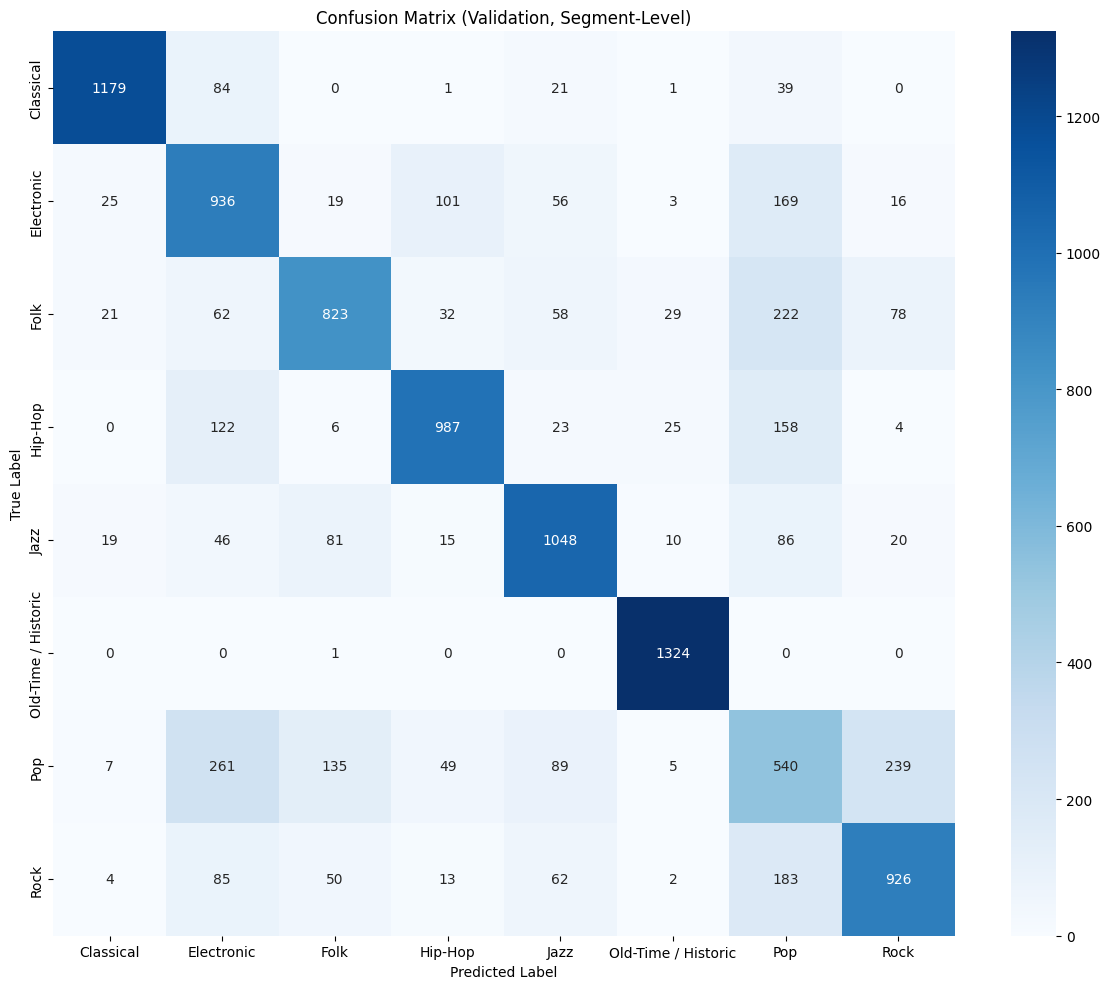


--- Validation Track-Level Evaluation (mean_probability) ---
Tracks evaluated: 424
Accuracy: 0.7642
Macro-F1: 0.7633

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.98      0.91      0.94        53
         Electronic       0.57      0.77      0.66        53
               Folk       0.76      0.66      0.71        53
            Hip-Hop       0.88      0.81      0.84        53
               Jazz       0.83      0.85      0.84        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.47      0.40      0.43        53
               Rock       0.72      0.72      0.72        53

           accuracy                           0.76       424
          macro avg       0.77      0.76      0.76       424
       weighted avg       0.77      0.76      0.76       424



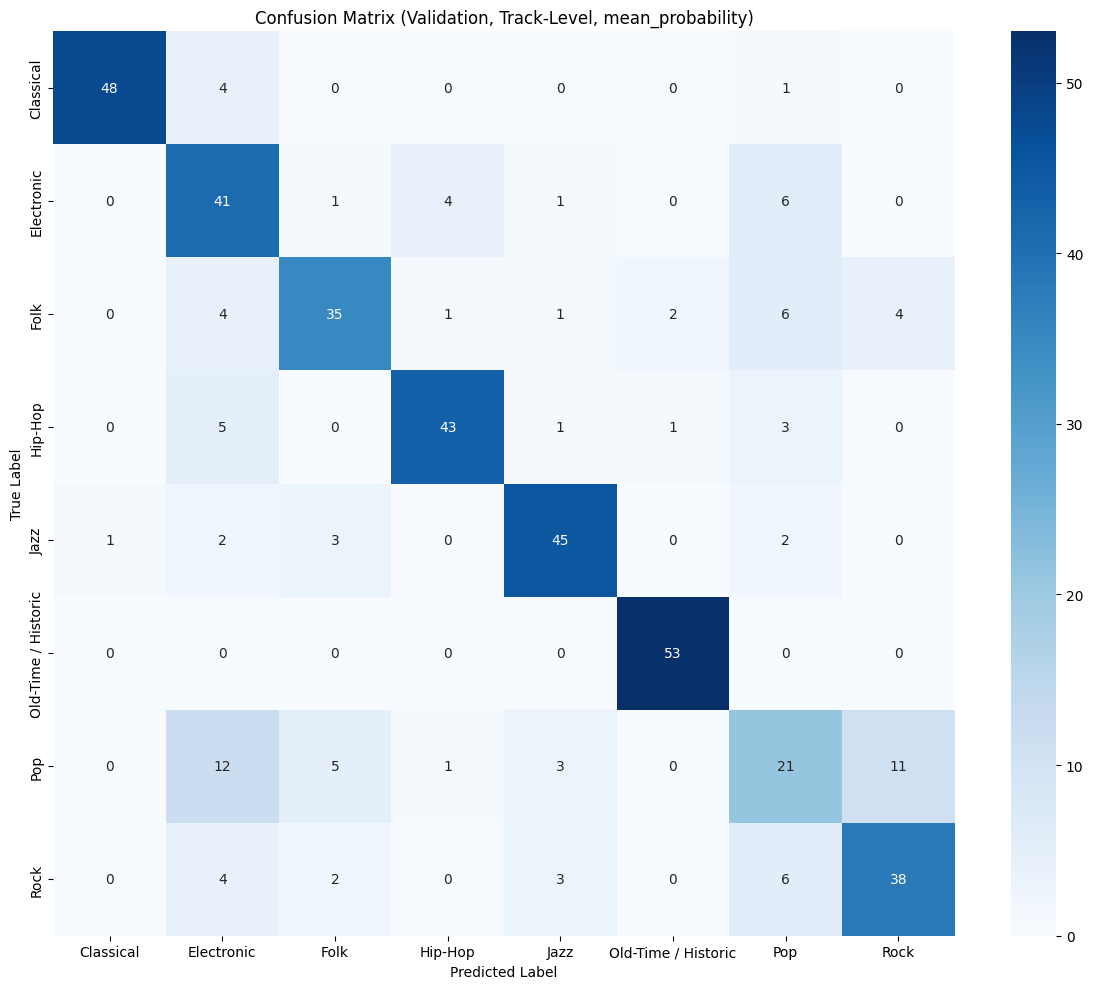


--- Validation Track-Level Evaluation (majority_vote) ---
Tracks evaluated: 424
Accuracy: 0.7642
Macro-F1: 0.7619

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.98      0.91      0.94        53
         Electronic       0.58      0.79      0.67        53
               Folk       0.77      0.70      0.73        53
            Hip-Hop       0.86      0.81      0.83        53
               Jazz       0.83      0.85      0.84        53
Old-Time / Historic       0.95      1.00      0.97        53
                Pop       0.44      0.36      0.40        53
               Rock       0.71      0.70      0.70        53

           accuracy                           0.76       424
          macro avg       0.77      0.76      0.76       424
       weighted avg       0.77      0.76      0.76       424



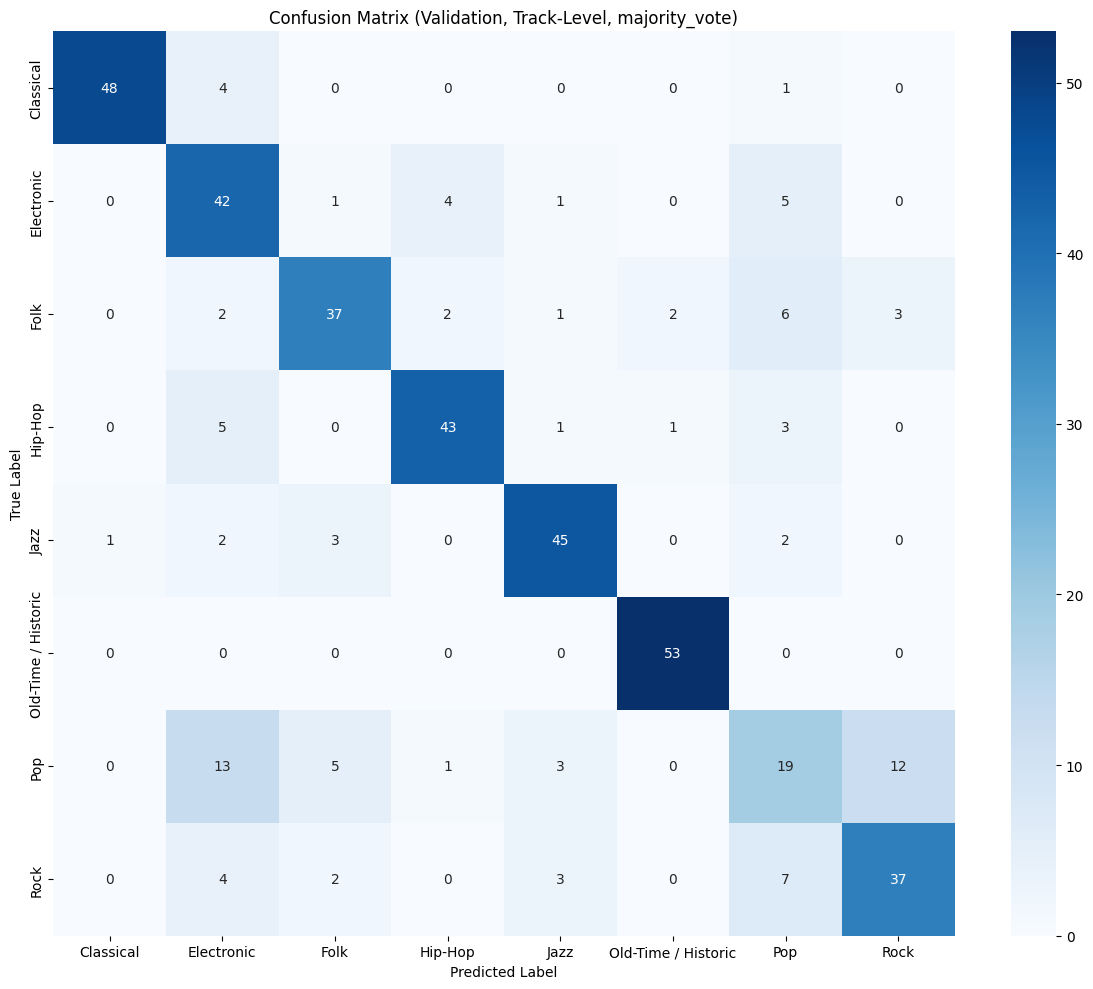


--- Test Segment-Level Evaluation ---
Segments evaluated: 10600
Accuracy: 0.7511
Macro-F1: 0.7476

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.91      0.89      0.90      1325
         Electronic       0.62      0.61      0.62      1325
               Folk       0.69      0.79      0.73      1325
            Hip-Hop       0.83      0.76      0.80      1325
               Jazz       0.80      0.74      0.77      1325
Old-Time / Historic       0.96      0.99      0.98      1325
                Pop       0.48      0.40      0.43      1325
               Rock       0.70      0.83      0.76      1325

           accuracy                           0.75     10600
          macro avg       0.75      0.75      0.75     10600
       weighted avg       0.75      0.75      0.75     10600



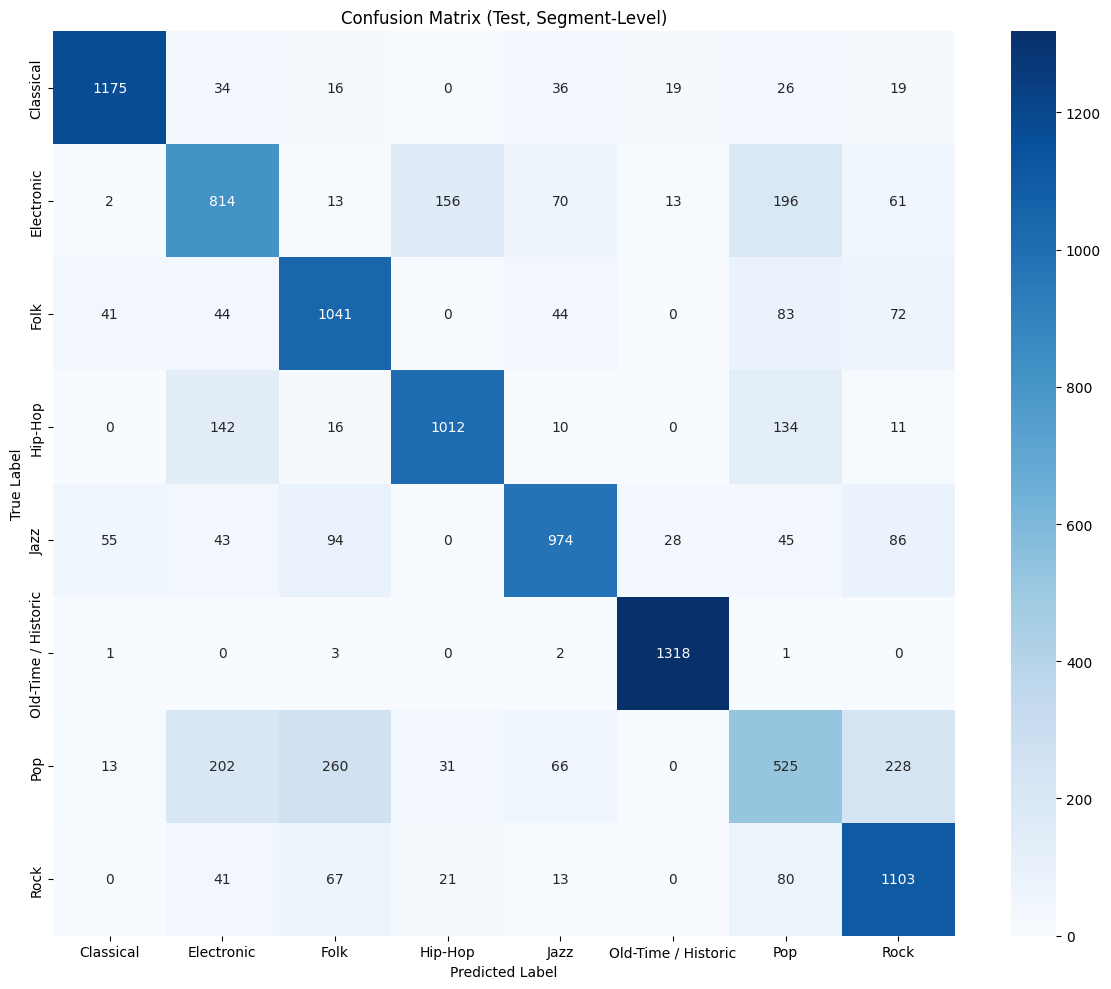


--- Test Track-Level Evaluation (mean_probability) ---
Tracks evaluated: 424
Accuracy: 0.7948
Macro-F1: 0.7901

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.94      0.91      0.92        53
         Electronic       0.67      0.66      0.67        53
               Folk       0.71      0.83      0.77        53
            Hip-Hop       0.88      0.83      0.85        53
               Jazz       0.86      0.79      0.82        53
Old-Time / Historic       0.96      1.00      0.98        53
                Pop       0.59      0.43      0.50        53
               Rock       0.73      0.91      0.81        53

           accuracy                           0.79       424
          macro avg       0.79      0.79      0.79       424
       weighted avg       0.79      0.79      0.79       424



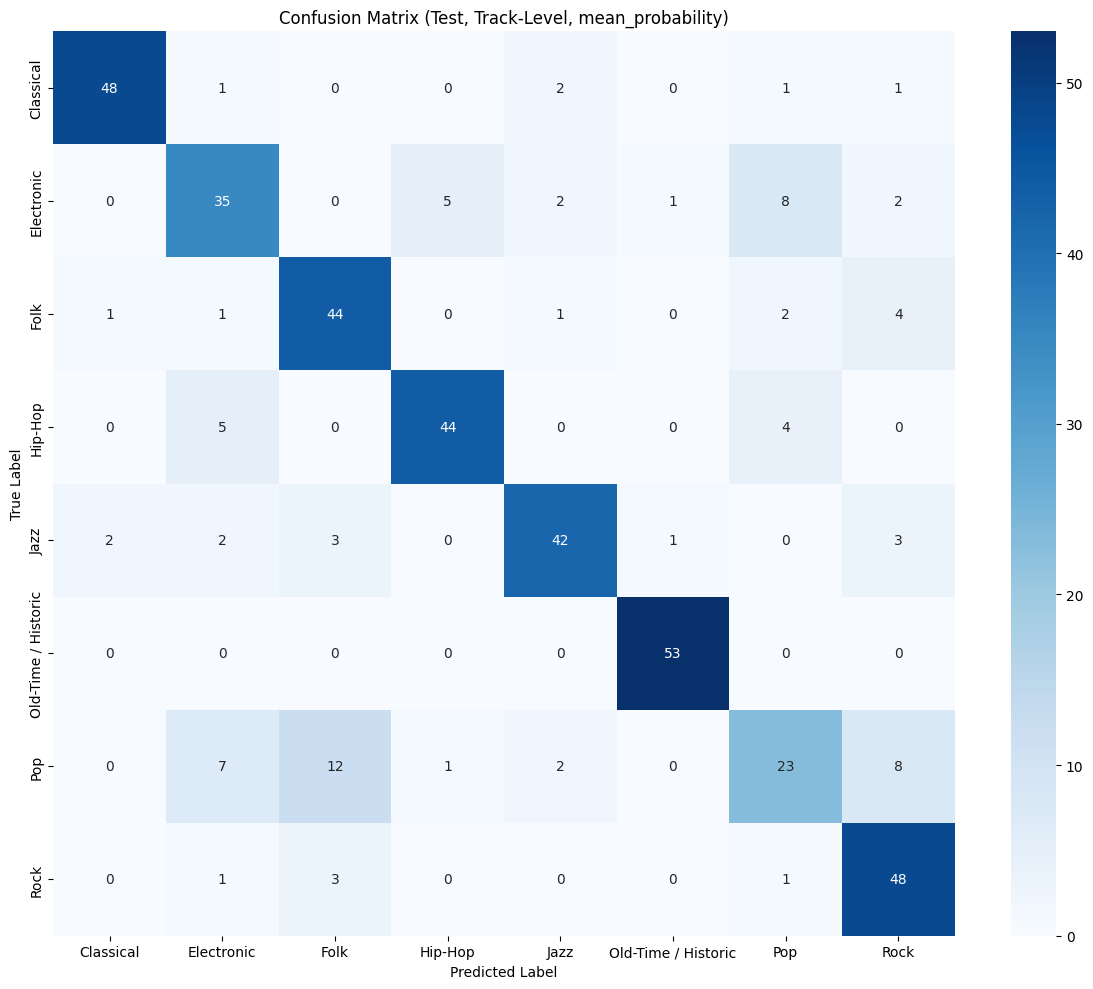


--- Test Track-Level Evaluation (majority_vote) ---
Tracks evaluated: 424
Accuracy: 0.7901
Macro-F1: 0.7849

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.92      0.92      0.92        53
         Electronic       0.66      0.66      0.66        53
               Folk       0.72      0.81      0.76        53
            Hip-Hop       0.88      0.79      0.83        53
               Jazz       0.86      0.81      0.83        53
Old-Time / Historic       0.96      1.00      0.98        53
                Pop       0.56      0.42      0.48        53
               Rock       0.73      0.91      0.81        53

           accuracy                           0.79       424
          macro avg       0.79      0.79      0.78       424
       weighted avg       0.79      0.79      0.78       424



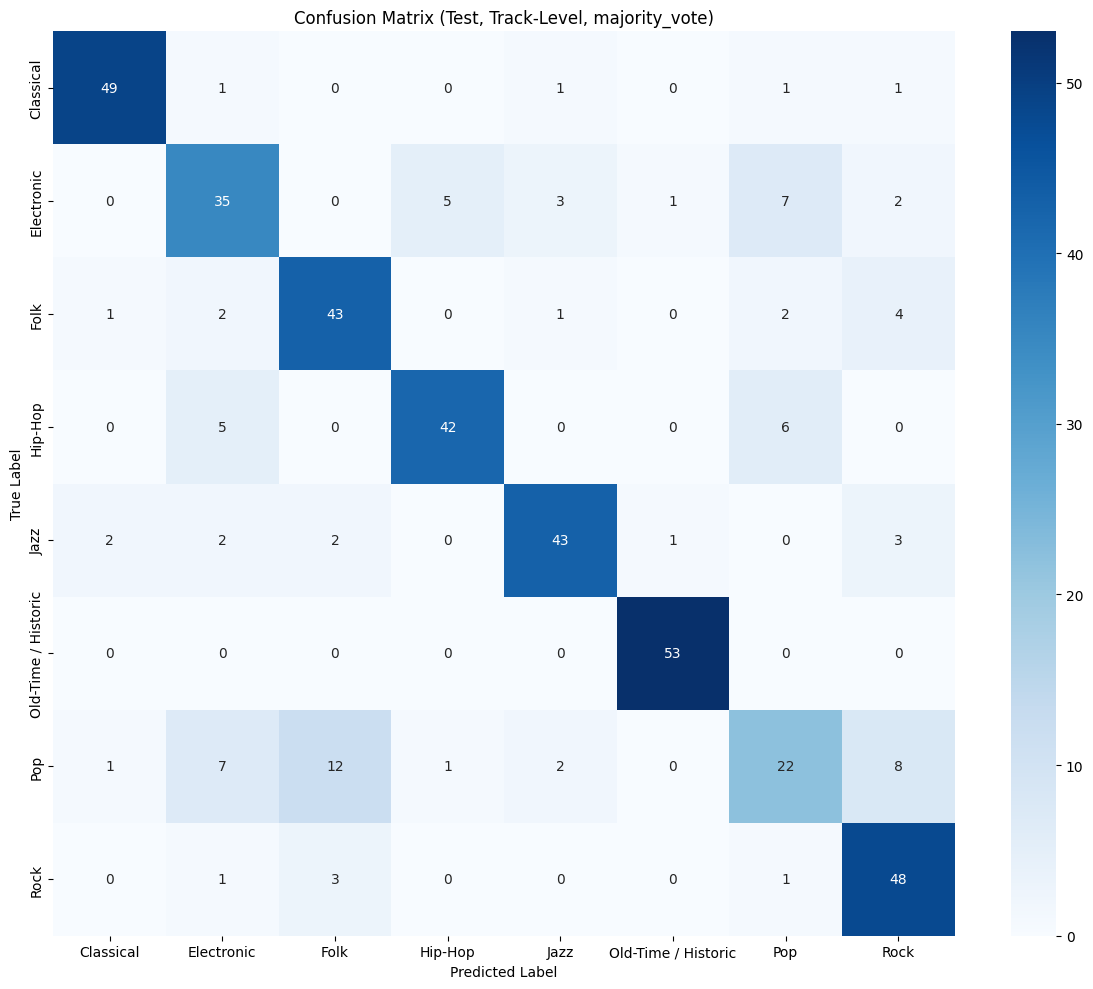

In [ ]:
# --------------------------------------------------------------
# RUN SEGMENT-LEVEL AND TRACK-LEVEL EVALUATION
# --------------------------------------------------------------

# Validation set
val_segment_df = collect_segment_predictions(model, val_loader)
evaluate_segment_predictions(val_segment_df, "Validation")

val_track_mean_df = aggregate_predictions_to_track(val_segment_df, method="mean_probability")
evaluate_track_predictions(val_track_mean_df, "Validation", method="mean_probability")

val_track_vote_df = aggregate_predictions_to_track(val_segment_df, method="majority_vote")
evaluate_track_predictions(val_track_vote_df, "Validation", method="majority_vote")


# Test set
test_segment_df = collect_segment_predictions(model, test_loader)
evaluate_segment_predictions(test_segment_df, "Test")

test_track_mean_df = aggregate_predictions_to_track(test_segment_df, method="mean_probability")
evaluate_track_predictions(test_track_mean_df, "Test", method="mean_probability")

test_track_vote_df = aggregate_predictions_to_track(test_segment_df, method="majority_vote")
evaluate_track_predictions(test_track_vote_df, "Test", method="majority_vote")



In [ ]:
# -------------------------------
# SAVE MISCLASSIFIED TRACKS
# -------------------------------
# This saves the track-level misclassifications based on mean-probability
# aggregation. This is usually the most informative result because one track
# contributes exactly one prediction.

if "test_track_mean_df" not in globals():
    test_segment_df = collect_segment_predictions(model, test_loader)
    test_track_mean_df = aggregate_predictions_to_track(
        test_segment_df,
        method="mean_probability"
    )

misclassified_tracks = test_track_mean_df[
    test_track_mean_df["true_label"] != test_track_mean_df["pred_label"]
].copy()

print(f"Number of misclassified tracks: {len(misclassified_tracks)}")
print(misclassified_tracks[["track_id", "true_genre", "predicted_genre", "n_segments"]].head())

results_dir = MODEL_RESULTS_DIR
os.makedirs(results_dir, exist_ok=True)

misclassified_tracks[[
    "track_id",
    "true_genre",
    "predicted_genre",
    "n_segments",
    "aggregation_method"
]].to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_misclassified_tracks_track_level_mean_probability.csv"),
    index=False
)

# Optional: also save all track-level test predictions for later analysis.
test_track_mean_df.to_csv(
    os.path.join(results_dir, f"{MODEL_NAME}_test_predictions_track_level_mean_probability.csv"),
    index=False
)



Number of misclassified tracks: 87
   track_id true_genre      predicted_genre  n_segments
9      1064       Jazz                 Rock          25
20    10975       Jazz  Old-Time / Historic          25
24   110750    Hip-Hop           Electronic          25
31   113023        Pop                 Jazz          25
37   114270    Hip-Hop                  Pop          25


In [ ]:
print(os.getcwd())

j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\Models_final\temp_Modelresults
